In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [43]:
def plot_with_complexity(csv_path):
    df = pd.read_csv(csv_path)

    n = df["n"].values
    t = df["time"].values
    complexity = df["complexity"].iloc[0]

    filename = os.path.basename(csv_path)
    name = filename.replace(".csv", "").replace("_", " ").title()

    def get_model(comp, n_vals):
        if comp == "O(1)": return np.ones_like(n_vals)
        if comp == "O(log n)": return np.log2(n_vals)
        if comp == "O(n)": return n_vals
        if comp == "O(n log n)": return n_vals * np.log2(n_vals)
        if comp == "O(n^2)": return n_vals**2
        if comp == "O(n^3)": return n_vals**3

    n_smooth = np.linspace(min(n), max(n), 200)

    plt.figure()

    plt.plot(n, t, marker='o', label="Real")

    if complexity == "O(1) or O(log n)":
        for comp in ["O(1)", "O(log n)"]:
            model_smooth = get_model(comp, n_smooth)
            scale = t[0] / get_model(comp, n)[0]
            model_smooth = model_smooth * scale

            plt.plot(n_smooth, model_smooth, '--', label=comp)

    else:
        if complexity in ["O(1)", "O(log n)", "O(n)", "O(n log n)", "O(n^2)", "O(n^3)"]:
            model_smooth = get_model(complexity, n_smooth)
            scale = t[0] / get_model(complexity, n)[0]
            model_smooth = model_smooth * scale

            plt.plot(n_smooth, model_smooth, '--', label=complexity)

    plt.xlabel("n")
    plt.ylabel("tempo (s)")
    plt.title(f"{name} | {complexity}")

    plt.legend()
    plt.grid()

    output_dir = "images"
    os.makedirs(output_dir, exist_ok=True)

    output_path = os.path.join(output_dir, filename.replace(".csv", ".png"))
    plt.savefig(output_path, dpi=300)

    print(f"Salvo em: {output_path}")

    plt.show()

In [44]:
csv_files = [f for f in os.listdir("results") if f.endswith(".csv")]
csv_files

['binary_search_best.csv',
 'binary_search_random.csv',
 'binary_search_worst.csv',
 'bubble_sort_best.csv',
 'bubble_sort_random.csv',
 'bubble_sort_worst.csv',
 'merge_sort_best.csv',
 'merge_sort_random.csv',
 'merge_sort_worst.csv',
 'sequencial_search_best.csv',
 'sequencial_search_random.csv',
 'sequencial_search_worst.csv']

In [45]:
path =  "results\\"

Salvo em: images\binary_search_best.png


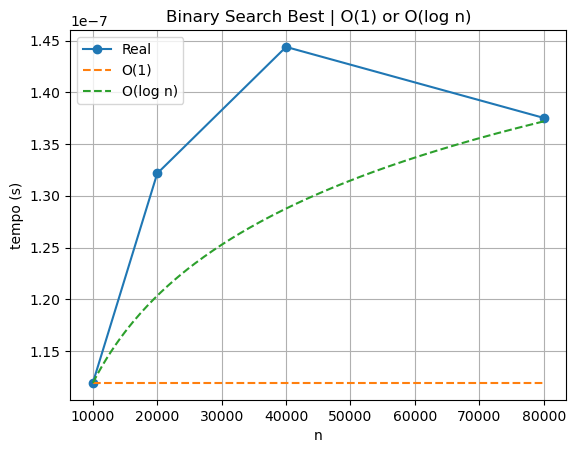

Salvo em: images\binary_search_random.png


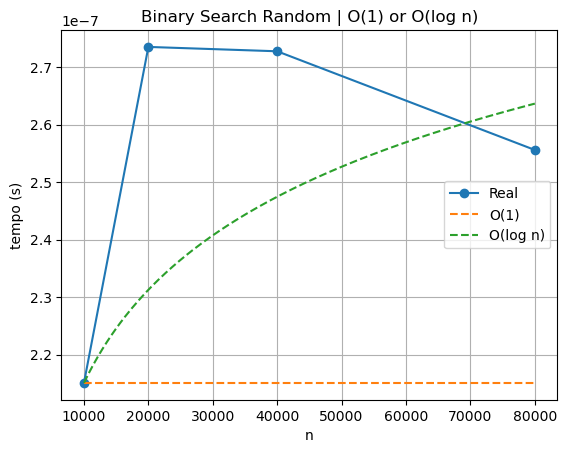

Salvo em: images\binary_search_worst.png


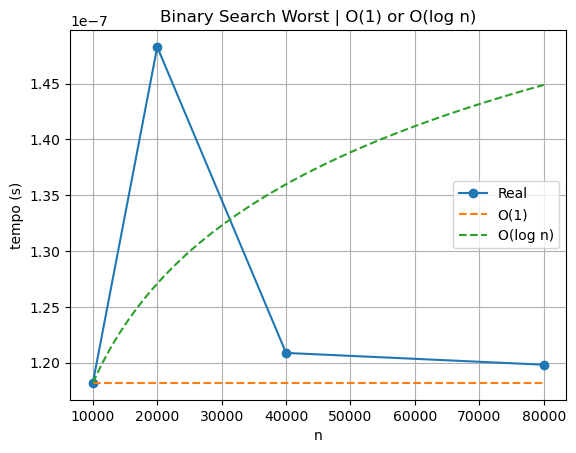

Salvo em: images\bubble_sort_best.png


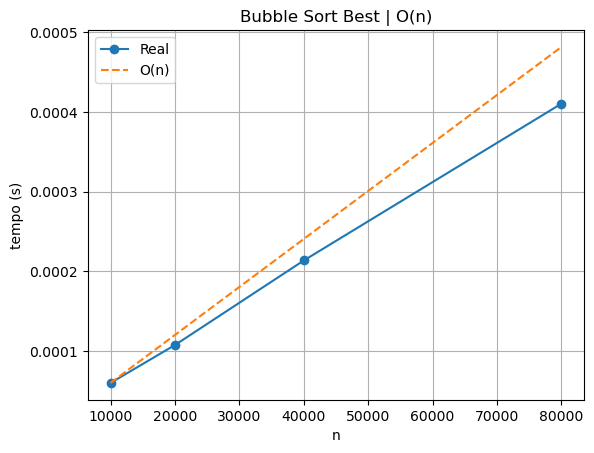

Salvo em: images\bubble_sort_random.png


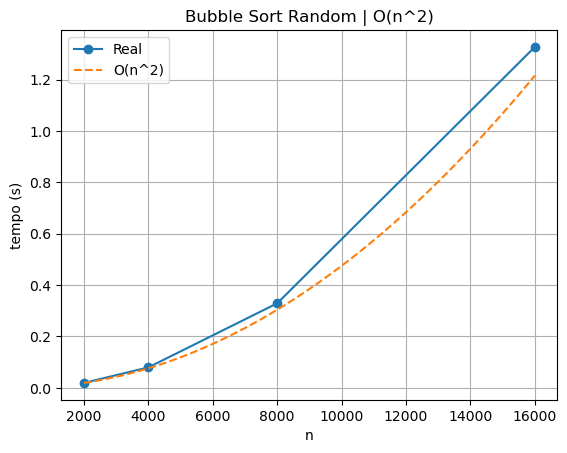

Salvo em: images\bubble_sort_worst.png


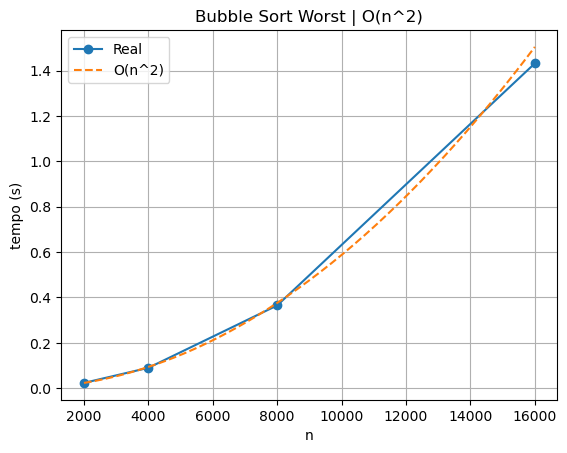

Salvo em: images\merge_sort_best.png


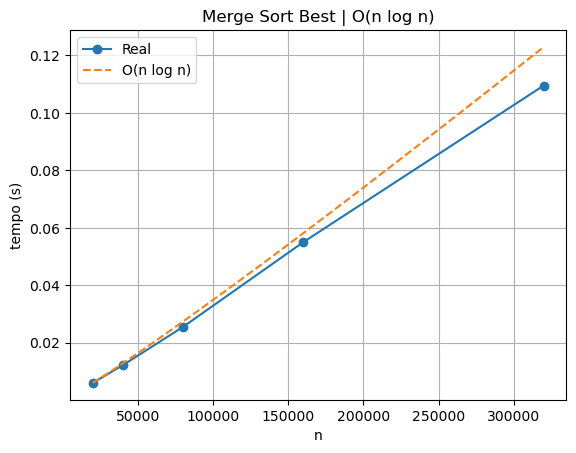

Salvo em: images\merge_sort_random.png


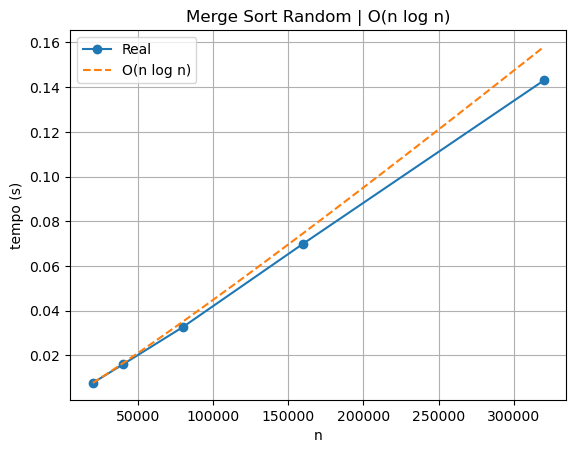

Salvo em: images\merge_sort_worst.png


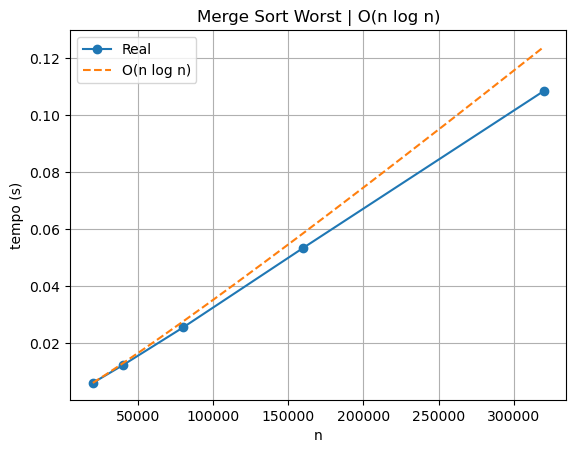

Salvo em: images\sequencial_search_best.png


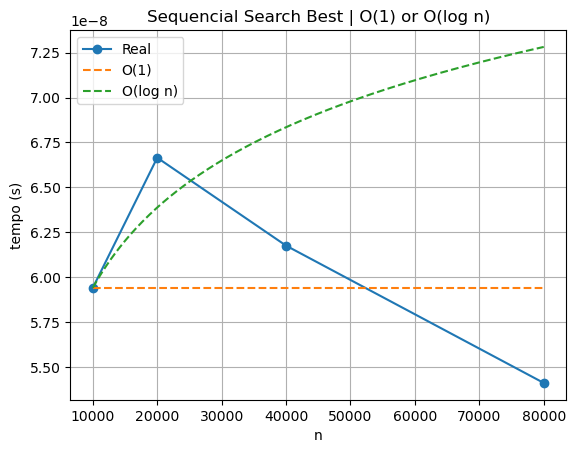

Salvo em: images\sequencial_search_random.png


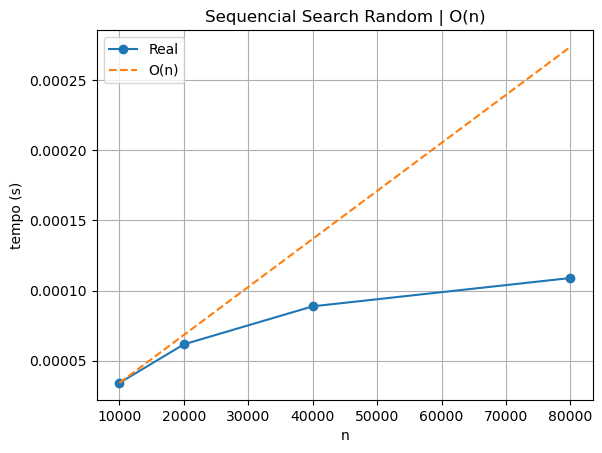

Salvo em: images\sequencial_search_worst.png


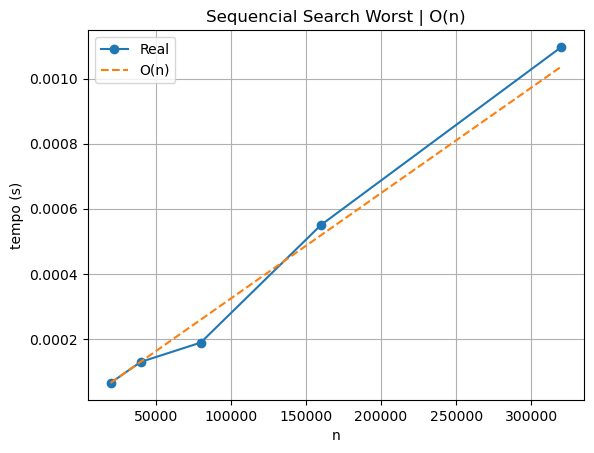

In [46]:
for c in csv_files:
    plot_with_complexity(path+c)